### EIGENFACES WITH PCA

In [7]:
# Loading and inspecting the dataset

from sklearn.datasets import fetch_lfw_people
import matplotlib.pyplot as plt
import numpy as np

In [3]:
faces = fetch_lfw_people(min_faces_per_person=10, resize=0.4)

In [4]:
print(faces.images.shape)

(4324, 50, 37)


In [5]:
print(faces.target_names)

['Abdullah Gul' 'Adrien Brody' 'Alejandro Toledo' 'Alvaro Uribe'
 'Amelie Mauresmo' 'Andre Agassi' 'Andy Roddick' 'Angelina Jolie'
 'Ann Veneman' 'Anna Kournikova' 'Ari Fleischer' 'Ariel Sharon'
 'Arnold Schwarzenegger' 'Atal Bihari Vajpayee' 'Bill Clinton'
 'Bill Gates' 'Bill McBride' 'Bill Simon' 'Britney Spears' 'Carlos Menem'
 'Carlos Moya' 'Catherine Zeta-Jones' 'Charles Moose' 'Colin Powell'
 'Condoleezza Rice' 'David Beckham' 'David Nalbandian' 'Dick Cheney'
 'Dominique de Villepin' 'Donald Rumsfeld' 'Edmund Stoiber'
 'Eduardo Duhalde' 'Fidel Castro' 'George HW Bush' 'George Robertson'
 'George W Bush' 'Gerhard Schroeder' 'Gloria Macapagal Arroyo'
 'Gonzalo Sanchez de Lozada' 'Gordon Brown' 'Gray Davis' 'Guillermo Coria'
 'Halle Berry' 'Hamid Karzai' 'Hans Blix' 'Harrison Ford'
 'Hillary Clinton' 'Howard Dean' 'Hu Jintao' 'Hugo Chavez' 'Ian Thorpe'
 'Igor Ivanov' 'Jack Straw' 'Jackie Chan' 'Jacques Chirac' 'Jacques Rogge'
 'James Blake' 'James Kelly' 'Jason Kidd' 'Javier Solana'

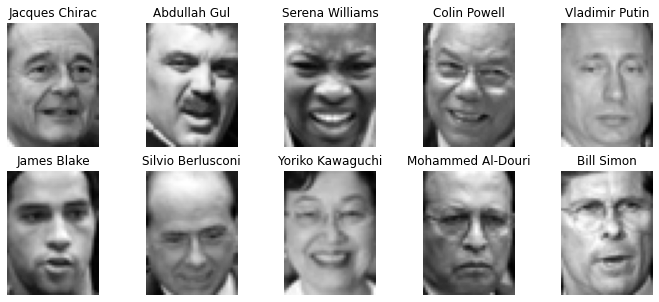

In [ ]:
# Visualizing few raw faces to confirmdata was loaded correctly
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap='gray')
    ax.set_title(faces.target_names[faces.target[i]])
    ax.axis('off')
plt.show(); 


Since each face image is currently a 2D array, I have to turn each one into a single 1D vector.  

In [8]:
# Each image (h x w) becomes a single row vector
X = faces.images.reshape(faces.images.shape[0], -1)

print(faces.images.shape)  # (n_samples, height, width)
print(X.shape)             # (n_samples, height*width)

(4324, 50, 37)
(4324, 1850)


### Mean-centering
I will perform mean-centering where we subtract the average face from every face so that PCA focuses on variation between faces and not the overall brightness/structure shared by all of them. 

In [ ]:
mean_face = X.mean(axis=0)  # average of all 4324 faces
X_centered = X - mean_face

print(mean_face.shape)    
print(X_centered.shape)  

(1850,)
(4324, 1850)


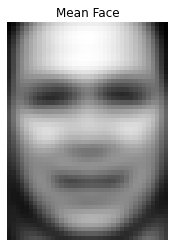

In [10]:
# Visualizing the mean face
plt.imshow(mean_face.reshape(50, 37), cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show();

### PCA

I will use `sklearn` to extract the top-k eigenfaces or principal components from the centred data. 

In [11]:
from sklearn.decomposition import PCA

k = 100 # number of eigenfaces to extract
pca = PCA(n_components=k)
pca.fit(X_centered)

PCA(n_components=100)

In [12]:
eigenfaces = pca.components_ # top-k eigenvectors 
print(eigenfaces.shape)

(100, 1850)


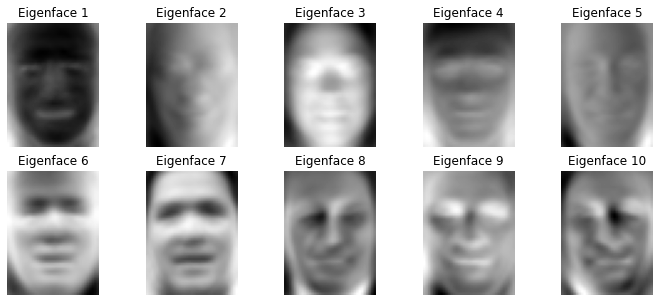

In [13]:
# Visualizing the first few eigenfaces

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(50, 37), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')
plt.show(); 

Each of the eigenface is a direction of maximum variance in face space. They appeared rather ghostly and I shall move forward to face reconstruction. Since we project a face into eigenface space (encode), the reconstruct it back (decode) using different numbers of components to see how quality improves. 

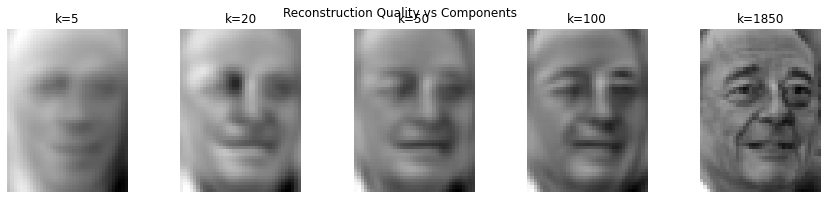

In [14]:
# Pick a face to reconstruct
face = X_centered[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
components = [5, 20, 50, 100, 1850]

for ax, k in zip(axes, components):
    pca_k = PCA(n_components=k)
    pca_k.fit(X_centered)
    reconstructed = pca_k.inverse_transform(pca_k.transform([face]))
    ax.imshow(reconstructed.reshape(50, 37), cmap='gray')
    ax.set_title(f'k={k}')
    ax.axis('off')

plt.suptitle('Reconstruction Quality vs Components')
plt.show(); 

The above visualization shows visually how adding more components recovers more facial detail. 

I shall now move on to plotting the explained variance below. The explained variance will show how much information each additional component captures. 

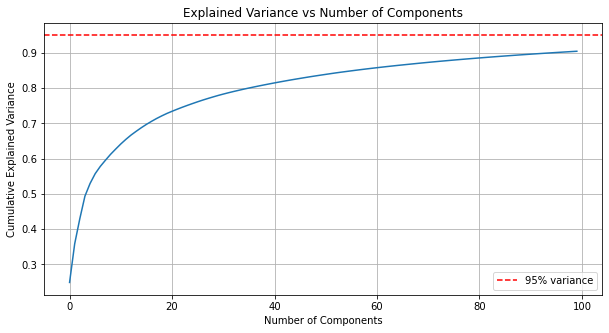

In [ ]:
pca_full = PCA(n_components=100)
pca_full.fit(X_centered)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.grid()
plt.show(); 

The above visualization tells of how many components needed to explain 95% of the variance and the point of diminishing returns where the curve flattens. 

### Manually computing eigenvalues/eigenvectors using NumPy to reinforce the theory

In [16]:
# Computing covariance matrix

cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix.shape) 

(1850, 1850)


In [17]:
# Computing eigenvalues and eigenvectors 
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [18]:
# Sorting by descending eigenvalue
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print(eigenvalues.shape)   
print(eigenvectors.shape)  

(1850,)
(1850, 1850)


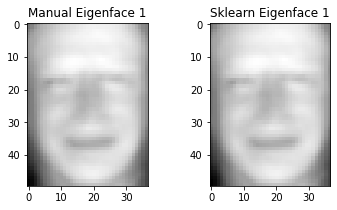

Manual top 5 variance ratios:   [0.24859902 0.10963932 0.07126692 0.06408979 0.03590716]
Sklearn top 5 variance ratios:  [0.24859896 0.10963937 0.07126696 0.06408975 0.03590718]


In [19]:
# Verifying manual results match sklearn's PCA 

# Take top 100 eigenvectors and compare with sklearn's components
manual_components = eigenvectors[:, :100].T  # (100, 1850)

# Compare first eigenface - they should look the same (may be flipped)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(np.abs(manual_components[0].reshape(50, 37)), cmap='gray')
axes[0].set_title('Manual Eigenface 1')
axes[1].imshow(np.abs(eigenfaces[0].reshape(50, 37)), cmap='gray')
axes[1].set_title('Sklearn Eigenface 1')
plt.show(); 

# Compare eigenvalues
manual_variance_ratio = eigenvalues[:100] / eigenvalues.sum()
print('Manual top 5 variance ratios:  ', manual_variance_ratio[:5].real)
print('Sklearn top 5 variance ratios: ', pca_full.explained_variance_ratio_[:5])

From the above visualization, the faces from the manual eigenface and sklearn eigenface are identical. The variance ratios as well match. 